In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
plt.style.use('Solarize_Light2')

In [56]:
ruta_dir = os.getcwd()
df=pd.read_parquet(os.path.join(ruta_dir,"..","data","c5_limpio.parquet"))

In [57]:
df

,dia_semana,tipo_incidente_c4,incidente_c4,alcaldia_inicio,codigo_cierre,clas_con_f_alarma,tipo_entrada,longitud,latitud,fecha,hora,mes,periodo,fin_semana
0,Miércoles,Accidente,Choque sin lesionados,IZTAPALAPA,1,EMERGENCIA,LLAMADA DEL 066,-99.061040,19.380900,2014-01-01,13,1,medio día,0
1,Miércoles,Accidente,Choque sin lesionados,GUSTAVO A. MADERO,1,EMERGENCIA,LLAMADA DEL 066,-99.103420,19.490530,2014-01-01,21,1,tarde,0
4,Miércoles,Accidente,Choque con lesionados,ALVARO OBREGON,1,URGENCIAS MEDICAS,LLAMADA DEL 066,-99.191040,19.363360,2014-01-01,21,1,tarde,0
5,Miércoles,Accidente,Choque sin lesionados,TLAHUAC,1,EMERGENCIA,LLAMADA DEL 066,-99.054880,19.295440,2014-01-01,19,1,tarde,0
6,Martes,Accidente,Choque con lesionados,AZCAPOTZALCO,1,URGENCIAS MEDICAS,LLAMADA DEL 066,-99.197810,19.482380,2013-12-31,19,12,tarde,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115075,Jueves,Accidente,Choque con lesionados,IZTAPALAPA,1,URGENCIAS MEDICAS,LLAMADA DEL 911,-99.087270,19.320600,2024-02-29,19,2,tarde,0
2115076,Jueves,Accidente,Choque con lesionados,CUAUHTEMOC,1,URGENCIAS MEDICAS,RADIO,-99.125200,19.428723,2024-02-29,20,2,tarde,0
2115077,Jueves,Accidente,Choque con lesionados,IZTAPALAPA,0,URGENCIAS MEDICAS,LLAMADA DEL 911,-99.119881,19.380011,2024-02-29,20,2,tarde,0
2115078,Jueves,Accidente,Motociclista,IZTAPALAPA,0,URGENCIAS MEDICAS,LLAMADA DEL 911,-99.080981,19.369412,2024-02-29,20,2,tarde,0


In [58]:
df.head(5)

df.dropna(inplace=True)
df.isna().sum()
df.shape

(2103612, 14)

In [59]:

columnas=df.columns
columnas=columnas.drop(["longitud","latitud","fecha","hora"])
columnas

Index(['dia_semana', 'tipo_incidente_c4', 'incidente_c4', 'alcaldia_inicio',
       'codigo_cierre', 'clas_con_f_alarma', 'tipo_entrada', 'mes', 'periodo',
       'fin_semana'],
      dtype='object')

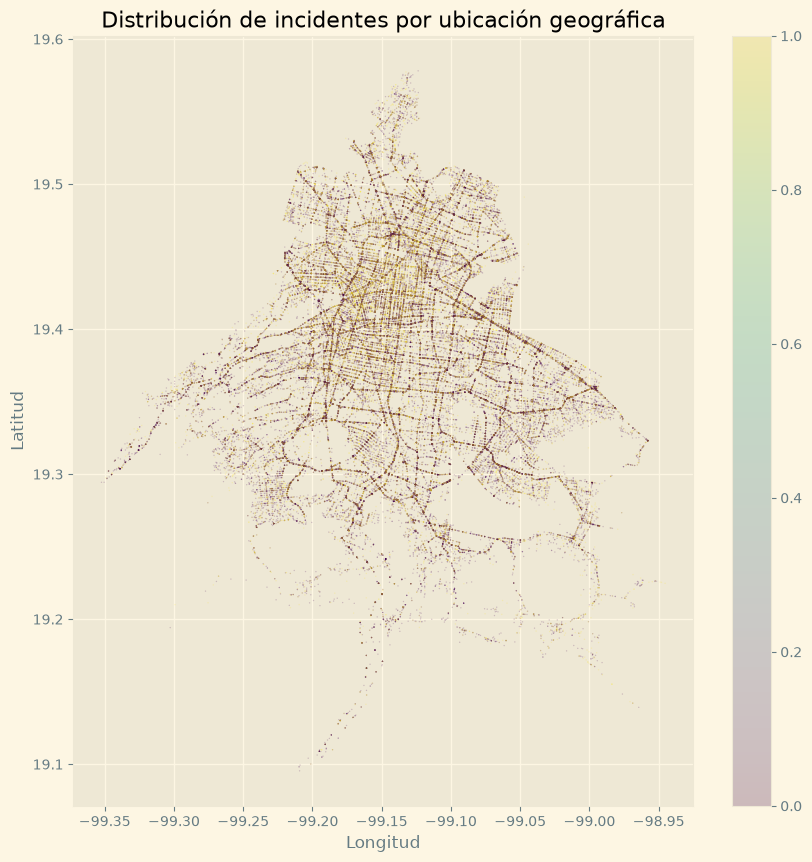

In [75]:
muestra=df.sample(100000,random_state=42)
plt.figure(figsize=(10,10))
plt.scatter(muestra["longitud"],muestra["latitud"], s=1,alpha=0.2, c=(muestra["codigo_cierre"]==1),edgecolor="none")
plt.colorbar()
plt.title("Distribución de incidentes por ubicación geográfica", color="Black")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()

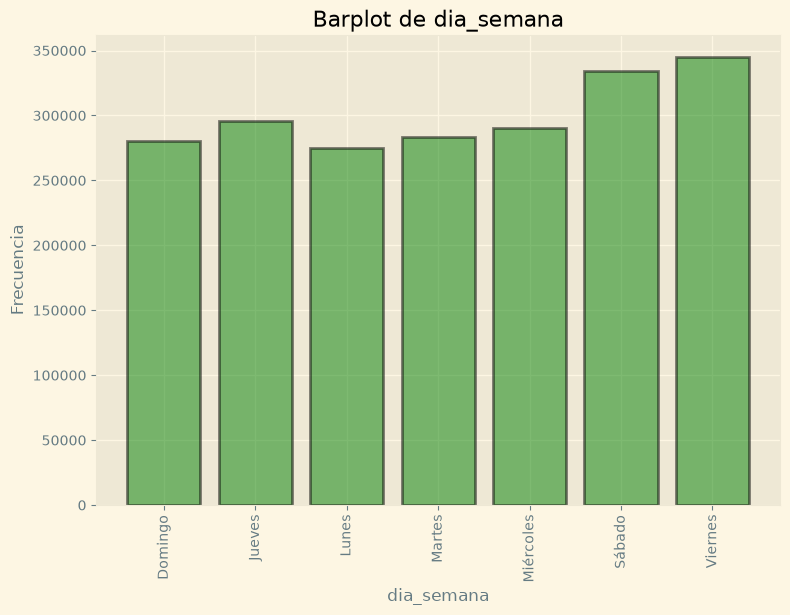

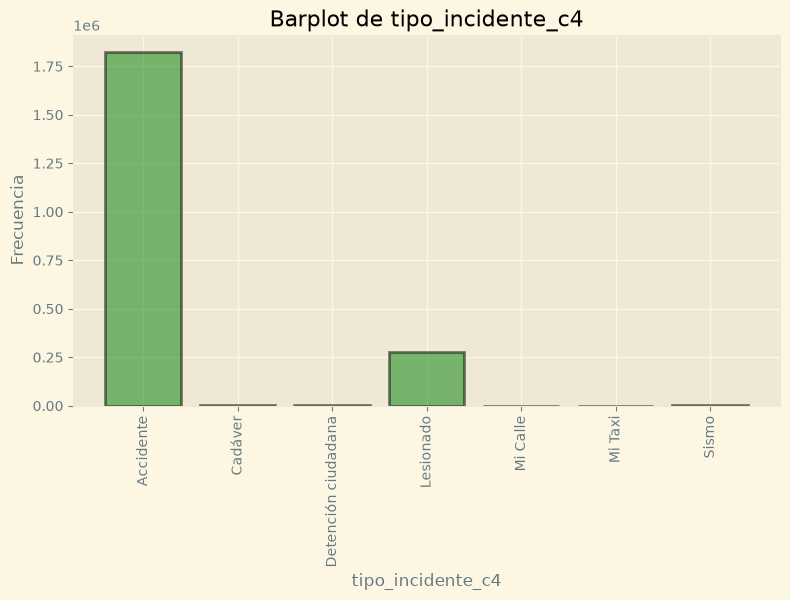

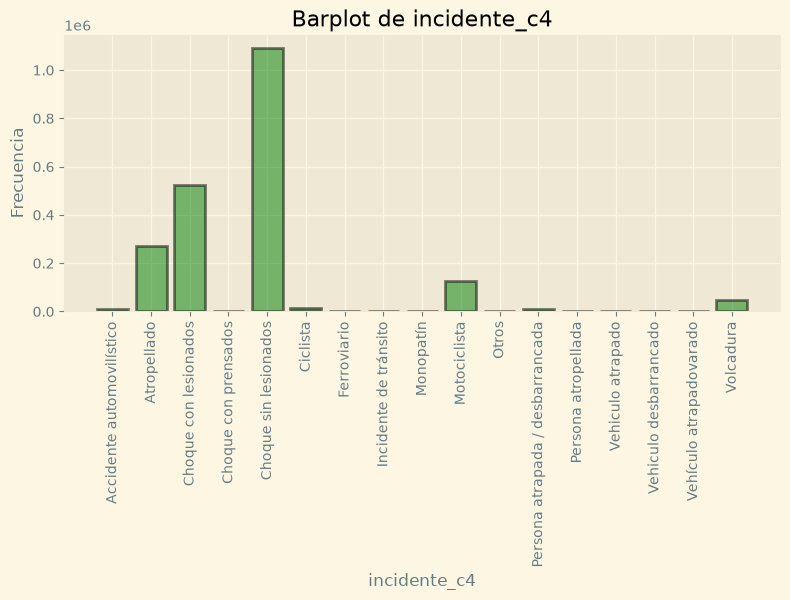

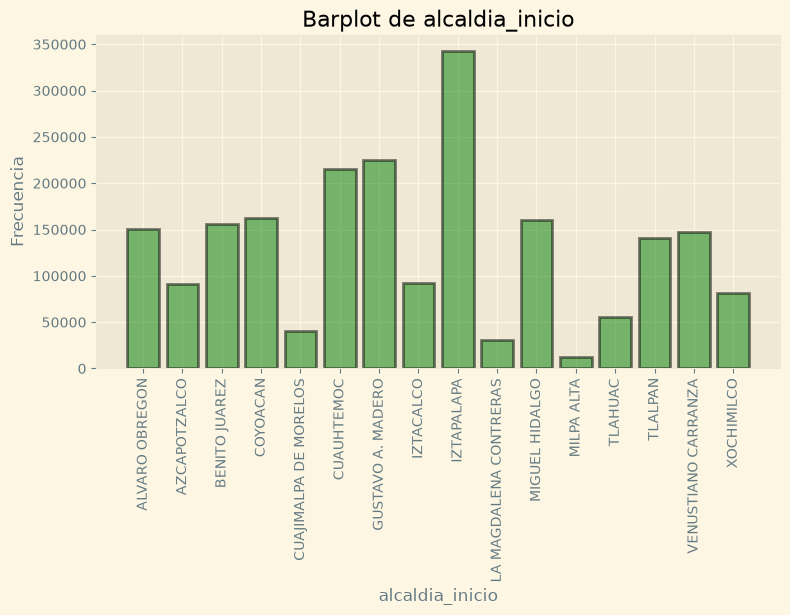

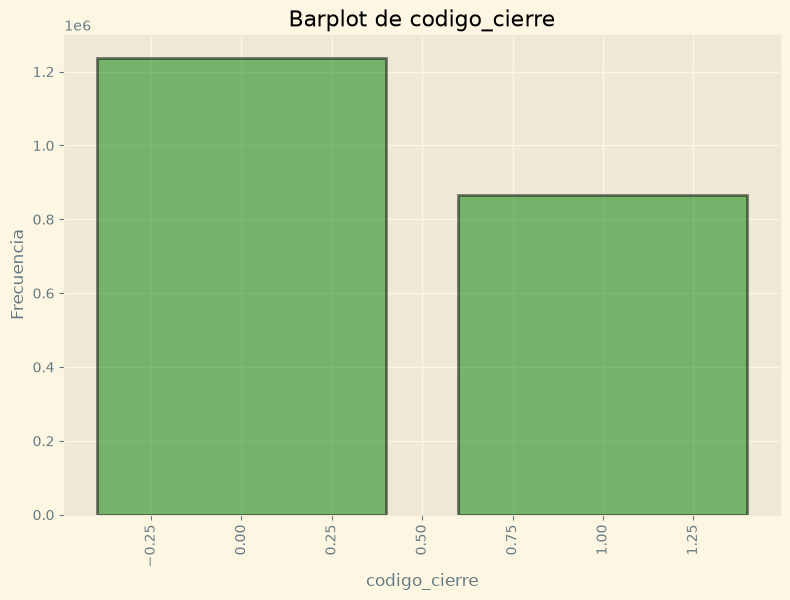

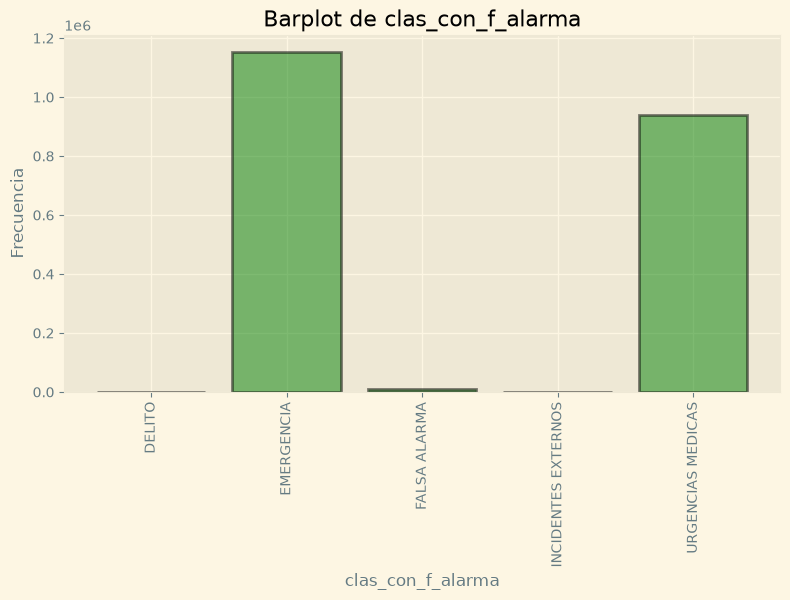

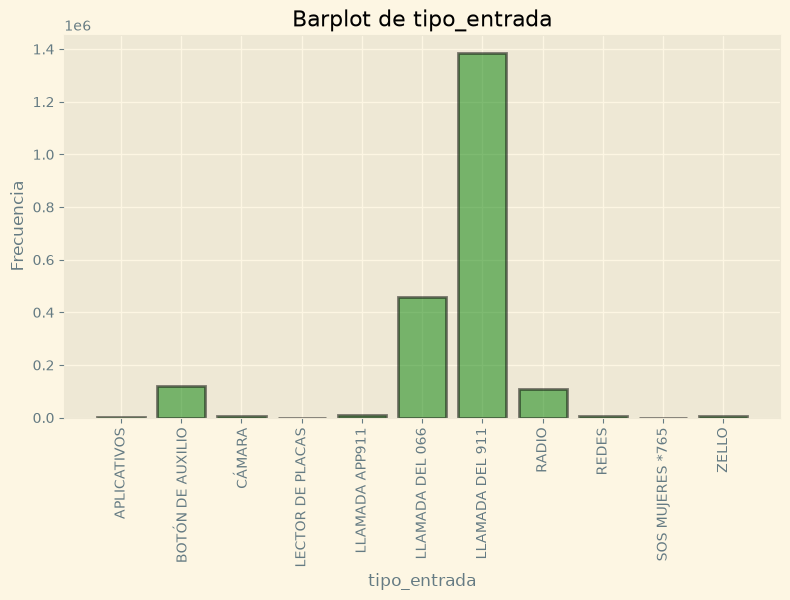

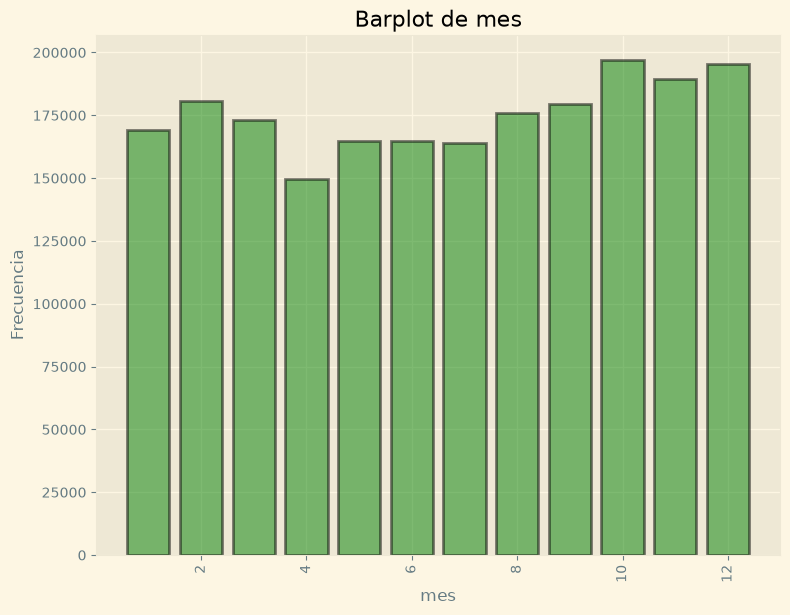

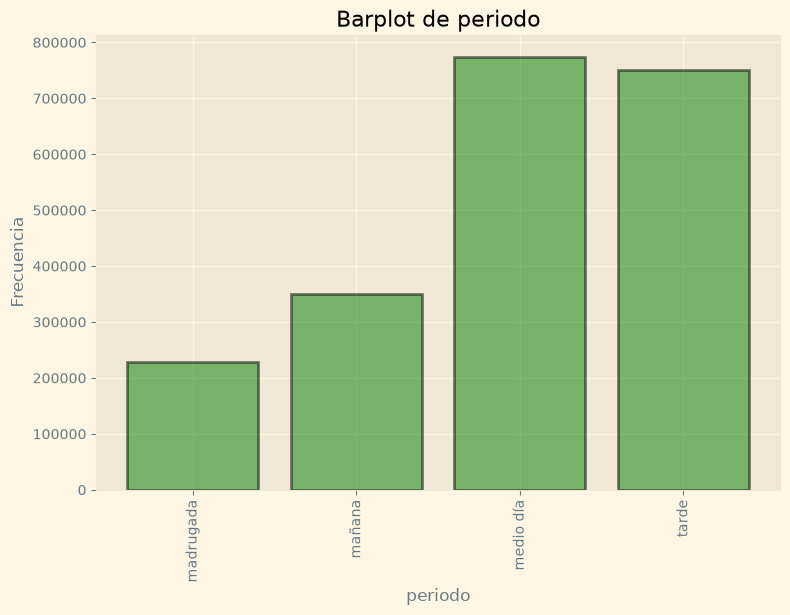

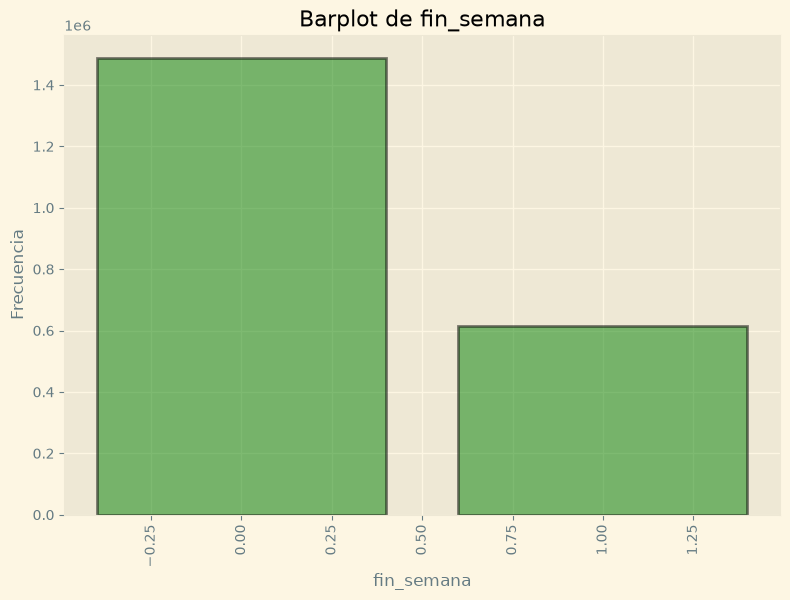

In [61]:
for col in columnas:
  plt.figure(figsize=(8,6))
  frecuencias=df[col].value_counts().sort_index()
  plt.bar(frecuencias.index,frecuencias.values,linewidth=2, color="green", alpha=0.5, edgecolor="black")
  plt.xticks(rotation=90)
  plt.xlabel(col)
  plt.ylabel("Frecuencia")
  plt.tight_layout()
  plt.title(f"Barplot de {col}", color="black")
  plt.show()



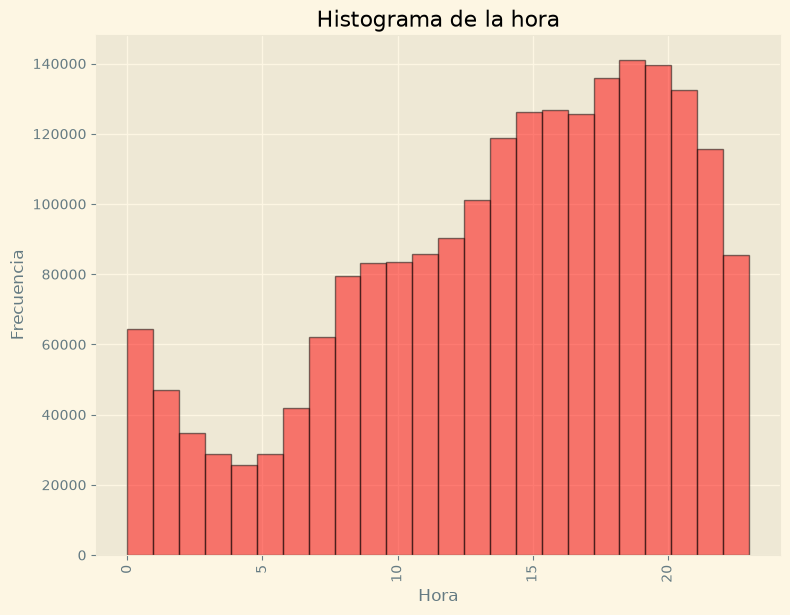

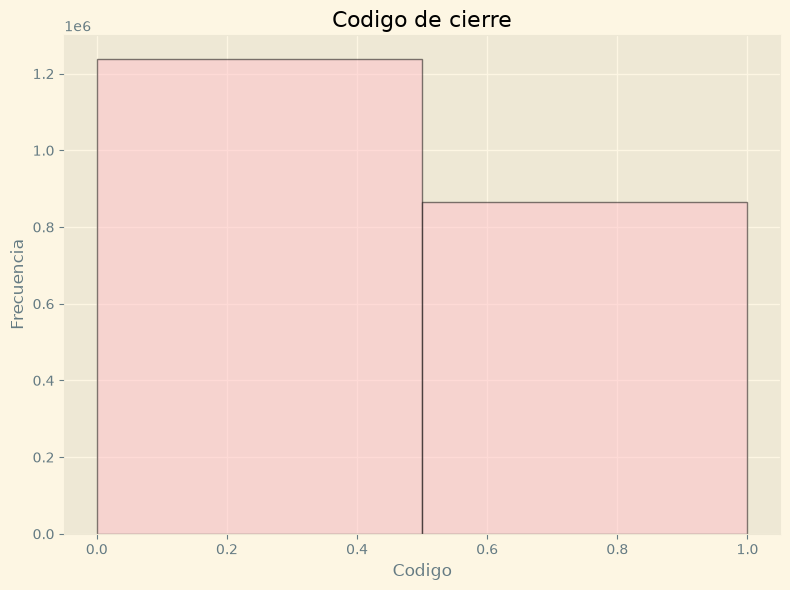

In [62]:
plt.figure(figsize=(8,6))
plt.hist(df["hora"],bins=24,linewidth=1,color="red", edgecolor="black", alpha=0.5)
plt.xticks(rotation=90)
plt.xlabel("Hora")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.title("Histograma de la hora", color="black")
plt.show()

plt.figure(figsize=(8,6))
plt.hist(df["codigo_cierre"],bins=2,edgecolor="black",linewidth=1, color="pink",alpha=0.5)
plt.title("Codigo de cierre", color="black")
plt.xlabel("Codigo")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [63]:
pd.crosstab(df["clas_con_f_alarma"],df["codigo_cierre"],margins=True,normalize="index")

codigo_cierre,0,1
clas_con_f_alarma,,
DELITO,0.779336,0.220664
EMERGENCIA,0.583201,0.416799
FALSA ALARMA,0.999630,0.000370
INCIDENTES EXTERNOS,0.600000,0.400000
URGENCIAS MEDICAS,0.590005,0.409995
All,0.588500,0.411500


In [64]:
pd.crosstab(
    df["tipo_incidente_c4"],
    df["codigo_cierre"],
    normalize="index"
)

codigo_cierre,0,1
tipo_incidente_c4,,
Accidente,0.590346,0.409654
Cadáver,0.136093,0.863907
Detención ciudadana,0.780309,0.219691
Lesionado,0.581768,0.418232
Mi Calle,0.970252,0.029748
Mi Taxi,0.727273,0.272727
Sismo,0.679694,0.320306


In [65]:
df.groupby("alcaldia_inicio")["codigo_cierre"].mean()

alcaldia_inicio
ALVARO OBREGON            0.385177
AZCAPOTZALCO              0.438794
BENITO JUAREZ             0.445415
COYOACAN                  0.407678
CUAJIMALPA DE MORELOS     0.344069
CUAUHTEMOC                0.493381
GUSTAVO A. MADERO         0.419350
IZTACALCO                 0.407891
IZTAPALAPA                0.368301
LA MAGDALENA CONTRERAS    0.374534
MIGUEL HIDALGO            0.438790
MILPA ALTA                0.442109
TLAHUAC                   0.403251
TLALPAN                   0.371326
VENUSTIANO CARRANZA       0.431192
XOCHIMILCO                0.348425
Name: codigo_cierre, dtype: float64

In [66]:
df.groupby("hora")["codigo_cierre"].mean()

hora
0     0.394740
1     0.402440
2     0.426793
3     0.441987
4     0.458698
5     0.466774
6     0.447570
7     0.469763
8     0.486553
9     0.480475
10    0.466819
11    0.448732
12    0.436856
13    0.415803
14    0.419794
15    0.417415
16    0.406075
17    0.390340
18    0.358402
19    0.372938
20    0.368779
21    0.364305
22    0.391294
23    0.397080
Name: codigo_cierre, dtype: float64

In [67]:
df.groupby("mes")["codigo_cierre"].mean()

mes
1     0.438515
2     0.427847
3     0.434789
4     0.438638
5     0.423797
6     0.412262
7     0.410609
8     0.401352
9     0.392312
10    0.394430
11    0.387464
12    0.388546
Name: codigo_cierre, dtype: float64

In [68]:
df.groupby("dia_semana")["codigo_cierre"].mean()

dia_semana
Domingo      0.401874
Jueves       0.416109
Lunes        0.417578
Martes       0.422584
Miércoles    0.421533
Sábado       0.399472
Viernes      0.404623
Name: codigo_cierre, dtype: float64

<Axes: xlabel='hora', ylabel='dia_semana'>

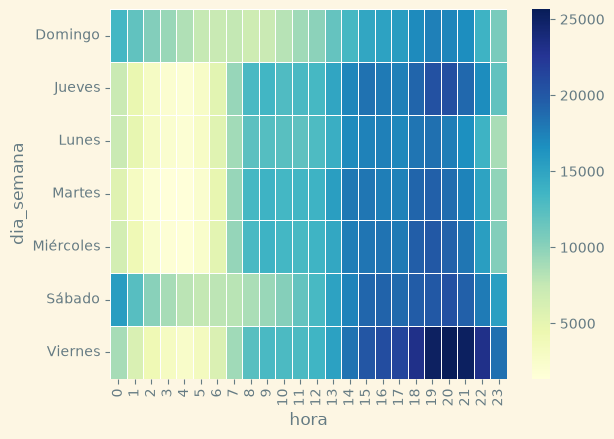

In [69]:
tabla=pd.crosstab(
    df["dia_semana"],
    df["hora"]
)

sns.heatmap(tabla,annot=False, fmt='.2f', cmap="YlGnBu", linewidths=0.5)

<Axes: xlabel='codigo_cierre', ylabel='hora'>

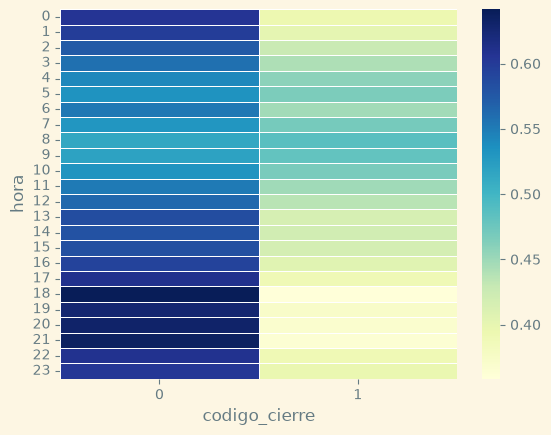

In [70]:
tabla=pd.crosstab(
    df["hora"],
    df["codigo_cierre"],
    normalize="index"
)
sns.heatmap(tabla,annot=False, fmt='.2f', cmap="YlGnBu", linewidths=0.5)

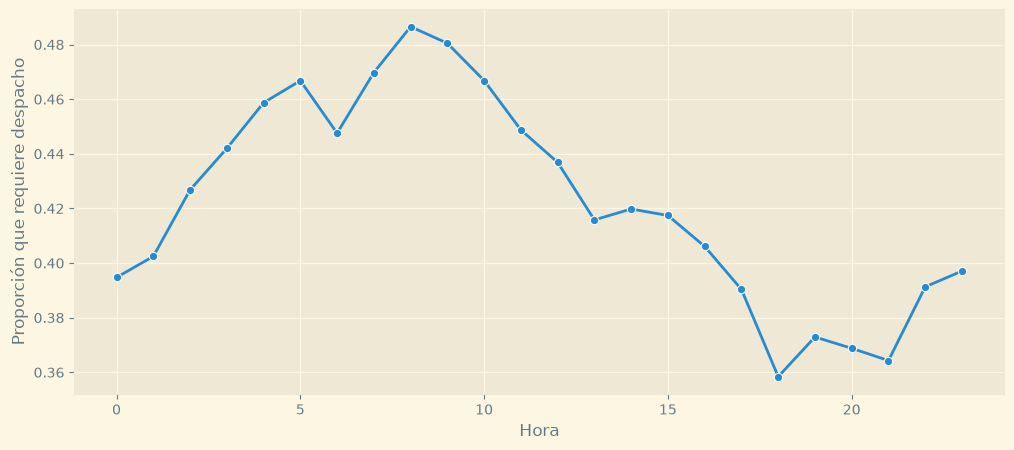

In [71]:
plt.figure(figsize=(12,5))
sns.lineplot(
    data=df.groupby("hora")["codigo_cierre"].mean().reset_index(),
    x="hora",
    y="codigo_cierre",
    marker="o"
)
plt.ylabel("Proporción que requiere despacho")
plt.xlabel("Hora")
plt.grid(True)